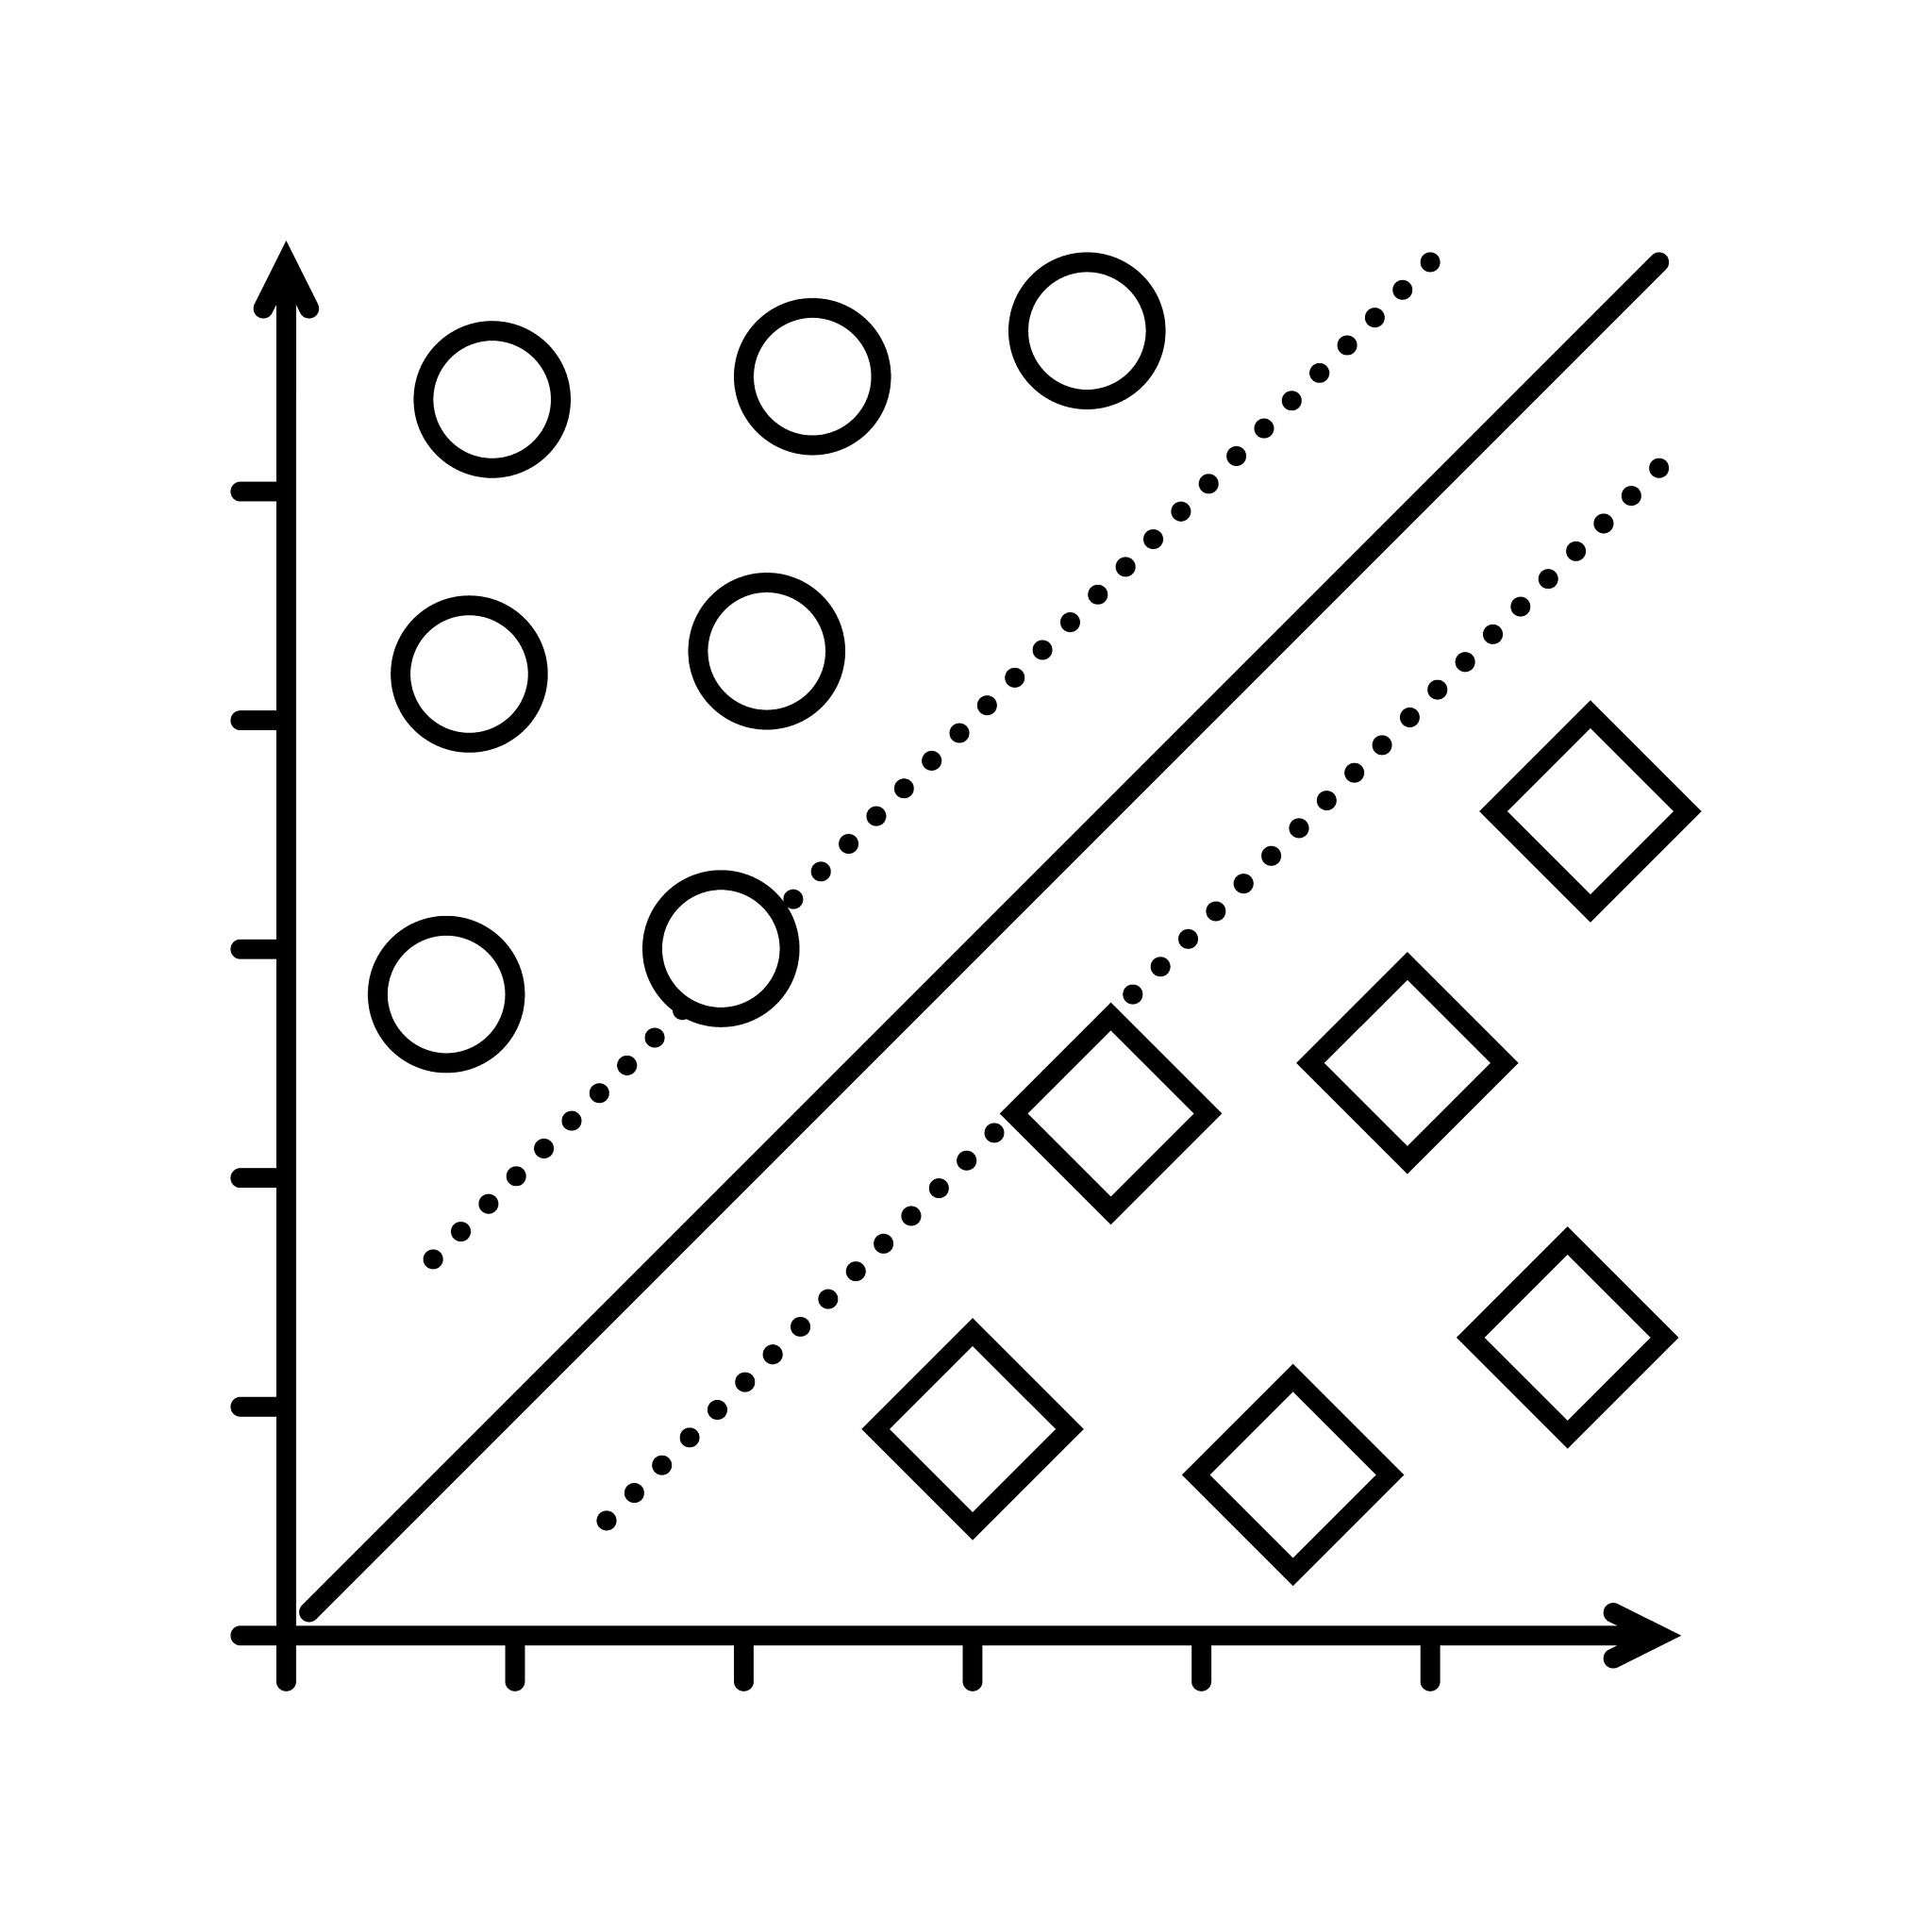

## Understanding Support Vector Machines (SVM)

Imagine you're separating two groups, like circles and diamonds, on a piece of paper. Your goal is to draw a straight line that clearly divides them.

Unlike some "lazy" algorithms (like Logistic Regression) that might draw any line, even one very close to a data point, **SVM aims for maximum safety**. It doesn't just draw a line; it builds the **widest possible empty "highway"** between the two groups. This "highway" represents the optimal separation.

### The "Widest Highway" Analogy

Imagine other algorithms (like Logistic Regression) are a bit "lazy." They'll draw *any* straight line that separates your groups. This line might pass extremely close to some data points. If a new, slightly varied data point comes along, it could easily get misclassified because the boundary is too narrow.

SVM, however, is obsessed with safety. It doesn't just draw a thin line; it aims to build the **widest possible empty highway** between the two groups. This wide separation makes the classification more robust and less prone to errors with new data.

### Key Components of an SVM Boundary

When SVM creates its classification boundary, it involves three specific parts:

*   **The Hyperplane (The Solid Line):** This is the actual decision boundary, the "painted yellow line" down the center of our highway. Points on one side are classified as one group, and points on the other side as the second group.

*   **The Margin (The Empty Space between Dotted Lines):** This is the total width of the highway itself, from one curb to the other. SVM's core mathematical goal is to maximize this margin. A wider margin means a more confident and stable classification.

*   **The Support Vectors (The Points Touching the Dotted Lines):** These are the critical data points that lie directly on the edges of the margin (the "curbs" of the highway). Interestingly, only these few points define the hyperplane and the margin. All other data points, far away from the boundary, don't influence its position at all. They are like the "pillars" holding up the entire highway structure.

### Handling Messy Data: Hard vs. Soft Margin

The previous example assumes perfectly separable data, but real-world data is often messy. What if some points from one group are mixed into the other?

*   **Hard Margin (The Perfectionist):** This type of SVM demands a perfect separation. It won't allow *any* data points inside the margin or on the wrong side of the hyperplane. If your data isn't perfectly separable, a Hard Margin SVM will fail to find a boundary or will create an overly complex one that doesn't generalize well.

*   **Soft Margin (The Realist):** This is the more practical approach. It introduces a "C" parameter, which acts like a tuning slider. A Soft Margin SVM allows for a few misclassifications or points to fall within the margin, in exchange for finding a wider and more generalized hyperplane. It prioritizes finding a *good* separation over a *perfect* but potentially unstable one.

# Hard-Margin Support Vector Machine (SVM)

Hard-Margin Support Vector Machine (SVM) is the simplest form of SVM. It assumes that the dataset is **perfectly linearly separable**, meaning a straight hyperplane can completely separate the two classes without making any classification errors.

The main objective of Hard-Margin SVM is **not just to separate the classes**, but to find the separating hyperplane with the **largest possible margin**, resulting in better generalization.

---

# 1. Translating the Geometry into Mathematics

Assume our dataset consists of feature vectors

$$
\mathbf{x}_i
$$

where each point belongs to one of two classes represented by

$$
y_i \in \{-1,+1\}.
$$

- $y_i = +1$ → Positive class
- $y_i = -1$ → Negative class

---

## The Decision Boundary (Hyperplane)

A linear decision boundary is represented by

$$
\mathbf{w}^\top\mathbf{x}+b=0
$$

where

- $\mathbf{w}$ = weight vector
- $b$ = bias (intercept)

The weight vector determines the **orientation** of the hyperplane, while the bias determines its **position**.

---

## The Margin Boundaries

Instead of having only one separating line, Hard-Margin SVM constructs two parallel boundaries called **margin hyperplanes**.

### Positive Margin

$$
H_1:\quad
\mathbf{w}^\top\mathbf{x}+b=1
$$

### Negative Margin

$$
H_2:\quad
\mathbf{w}^\top\mathbf{x}+b=-1
$$

The region between these two hyperplanes is called the **margin**.

---

## Why Exactly +1 and −1?

One interesting property of a linear equation is that multiplying both $\mathbf{w}$ and $b$ by any non-zero constant does **not** change the location of the decision boundary.

For example,

$$
\mathbf{w}^\top\mathbf{x}+b=0
$$

and

$$
5\mathbf{w}^\top\mathbf{x}+5b=0
$$

represent the **same hyperplane**.

Since infinitely many equivalent representations exist, we normalize the equations by forcing the closest training points (called **Support Vectors**) to satisfy

$$
\mathbf{w}^\top\mathbf{x}+b=\pm1.
$$

This establishes a fixed mathematical scale for measuring the margin.

---

# 2. Hard-Margin Constraints

Hard-Margin SVM follows a **zero-tolerance policy**.

That means

- No point may lie inside the margin.
- No point may lie on the wrong side of the hyperplane.
- Every training sample must be classified correctly.

---

## Constraint for Positive Class

For every positive sample,

$$
y_i=+1,
$$

the point must satisfy

$$
\mathbf{w}^\top\mathbf{x}_i+b\ge1.
$$

---

## Constraint for Negative Class

For every negative sample,

$$
y_i=-1,
$$

the point must satisfy

$$
\mathbf{w}^\top\mathbf{x}_i+b\le-1.
$$

---

## Unified Hard-Margin Constraint

Instead of maintaining two separate inequalities, both constraints can be combined into one elegant equation:

$$
y_i\left(\mathbf{w}^\top\mathbf{x}_i+b\right)\ge1,
\qquad
i=1,2,\ldots,N.
$$

where

- $N$ = total number of training samples
- $\mathbf{x}_i$ = feature vector
- $y_i$ = class label
- $\mathbf{w}$ = weight vector
- $b$ = bias

> **Important:**  
> If **even one training sample** violates this constraint, Hard-Margin SVM cannot find a valid solution.

---

# 3. Calculating the Width of the Margin

The objective of Hard-Margin SVM is to maximize the distance between the two margin hyperplanes.

Suppose

- $\mathbf{x}_+$ is a positive support vector.
- $\mathbf{x}_-$ is a negative support vector.

Since both lie exactly on the margin,

$$
\mathbf{w}^\top\mathbf{x}_+ + b = 1
$$

and

$$
\mathbf{w}^\top\mathbf{x}_- + b = -1.
$$

Rearranging,

$$
\mathbf{w}^\top\mathbf{x}_+=1-b
$$

and

$$
\mathbf{w}^\top\mathbf{x}_-=-1-b.
$$

---

## Distance Between the Two Hyperplanes

The width of the margin equals the projection of

$$
\mathbf{x}_+-\mathbf{x}_-
$$

onto the unit vector perpendicular to the hyperplane,

$$
\frac{\mathbf{w}}{\|\mathbf{w}\|}.
$$

Therefore,

$$
\text{Margin Width}
=
(\mathbf{x}_+-\mathbf{x}_-)
\cdot
\frac{\mathbf{w}}{\|\mathbf{w}\|}
=
\frac{
\mathbf{w}^\top\mathbf{x}_+
-
\mathbf{w}^\top\mathbf{x}_-
}
{\|\mathbf{w}\|}.
$$

Substituting the support-vector equations,

$$
=
\frac{
(1-b)-(-1-b)
}
{\|\mathbf{w}\|}
=
\frac{2}{\|\mathbf{w}\|}.
$$

---

## Final Margin Formula

The width of the margin is

$$
\boxed{
\text{Margin Width}
=
\frac{2}{\|\mathbf{w}\|}
}
$$

Since the numerator is constant,

maximizing the margin is exactly equivalent to minimizing

$$
\|\mathbf{w}\|.
$$

---

# 4. The Optimization Problem

Our objective is

$$
\max
\frac{2}{\|\mathbf{w}\|}.
$$

Since the numerator is constant,

this becomes

$$
\min
\|\mathbf{w}\|.
$$

For easier differentiation and optimization, mathematicians square the norm and multiply by $\frac12$.

Thus the optimization problem becomes

$$
\boxed{
\begin{aligned}
\min_{\mathbf{w},\,b}
\quad&
\frac12\|\mathbf{w}\|^2
\\[0.4cm]
\text{subject to}
\quad&
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1,
\qquad
i=1,\ldots,N.
\end{aligned}
}
$$

This is a **Quadratic Programming (QP)** optimization problem.

Because the objective function is **convex**, it possesses **exactly one global optimum**.

If a feasible solution exists, the optimizer is guaranteed to find it.

---

# Why Do We Need Hard-Margin SVM?

Hard-Margin SVM demonstrates one of the most important ideas in machine learning:

> **Structural Risk Minimization (SRM)**

Instead of fitting every tiny fluctuation in the training data, SVM intentionally searches for the **widest possible margin**, which generally leads to better generalization.

Minimizing

$$
\|\mathbf{w}\|^2
$$

forces the classifier to remain as simple as possible while still separating the data.

Hard-Margin SVM is particularly useful for

- perfectly linearly separable datasets,
- theoretical machine learning analysis,
- high-dimensional scientific datasets (such as genomics),
- situations where training data contains virtually no noise.

---

# Limitations of Hard-Margin SVM

Although mathematically elegant, Hard-Margin SVM rarely works well in real-world datasets.

There are two major reasons.

---

# Failure 1: Sensitivity to Outliers

Imagine a dataset containing **1,000 perfectly separated samples**.

Hard-Margin SVM constructs a beautiful, wide margin.

Now suppose **one noisy outlier** appears because of a measurement error.

Since every point must satisfy

$$
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1,
$$

the optimizer is forced to

- rotate the hyperplane,
- shrink the margin,
- completely change the classifier,

simply to accommodate that single noisy observation.

As a result,

the classifier's ability to generalize becomes significantly worse.

---

# Failure 2: Non-Linearly Separable Data

Suppose the dataset contains slight overlap.

| Feature 1 | Feature 2 | Class |
|-----------|-----------|-------|
| 1.2 | 3.4 | +1 |
| 1.5 | 3.1 | -1 |

Now no straight line can perfectly separate the two classes.

The optimization constraints become contradictory.

There is **no** $(\mathbf{w},b)$ satisfying

$$
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1
$$

for every training sample.

Consequently,

the optimization solver reports

> **No feasible solution exists.**

---

# The Bridge to Soft-Margin SVM

Real-world datasets almost always contain

- measurement noise,
- overlapping classes,
- mislabeled samples,
- outliers.

To handle these situations, Hard-Margin SVM is extended into **Soft-Margin SVM**.

The key idea is to introduce a **Slack Variable**

$$
\xi_i\ge0.
$$

The hard constraint becomes

$$
y_i(\mathbf{w}^\top\mathbf{x}_i+b)
\ge
1-\xi_i.
$$

The slack variable allows certain training samples to

- enter the margin,
- touch the decision boundary,
- or even be misclassified.

However, every violation incurs a penalty controlled by the regularization parameter

$$
C.
$$

Thus, Soft-Margin SVM balances two competing objectives:

- maximizing the margin,
- minimizing classification errors.

This makes Soft-Margin SVM far more practical for real-world machine learning problems.

---

# Summary

Hard-Margin SVM seeks the hyperplane that **maximizes the margin** while **perfectly separating** every training sample.

Its optimization problem is

$$
\boxed{
\begin{aligned}
\min_{\mathbf{w},b}
\quad&
\frac12\|\mathbf{w}\|^2
\\[0.4cm]
\text{subject to}
\quad&
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1.
\end{aligned}
}
$$

Although mathematically elegant and theoretically important, Hard-Margin SVM is extremely sensitive to outliers and completely fails whenever the data is not perfectly linearly separable. These limitations naturally motivate the development of the **Soft-Margin SVM**, which introduces slack variables to achieve better robustness and real-world applicability.

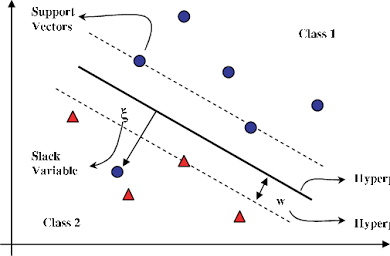

# Soft-Margin Support Vector Machine (SVM)

Unlike **Hard-Margin SVM**, which assumes that every training sample must be perfectly classified, **Soft-Margin SVM** recognizes that real-world datasets are often noisy, contain outliers, or are not perfectly linearly separable.

Instead of enforcing a strict **zero-error policy**, Soft-Margin SVM allows controlled violations of the margin while penalizing them during optimization.

---

# 1. The Mathematics: Introducing the Slack Variable

To allow classification mistakes without breaking the mathematical optimization problem, we introduce a new variable called the **Slack Variable**.

It is denoted by the Greek letter

$$
\xi_i
$$

(pronounced **"zai"** or **"ksi"**).

Each training sample receives **its own** slack variable.

Geometrically, the slack variable measures **how much a data point violates its assigned margin**.

For example, if a data point crosses inside the margin—or even crosses the decision boundary—the corresponding slack variable quantifies the amount of that violation.

---

## Updated Constraint Equation

The hard-margin constraint

$$
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1
$$

is replaced with

$$
\boxed{
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1-\xi_i,
\qquad
\xi_i\ge0
}
$$

where

- $\xi_i$ = slack variable for the $i^{\text{th}}$ training sample
- $\xi_i \ge 0$ ensures that violations are never negative.

---

## Interpretation of the Slack Variable

The value of $\xi_i$ tells us exactly how well a training sample satisfies the margin requirement.

### Case 1: No Violation

If

$$
\xi_i=0,
$$

then the sample lies **on or outside its correct margin**.

The point is perfectly classified and does not violate the margin.

---

### Case 2: Margin Violation

If

$$
0<\xi_i\le1,
$$

the sample lies **inside the margin**, but it is **still on the correct side** of the decision boundary.

The point is correctly classified, although the margin requirement is violated.

---

### Case 3: Misclassification

If

$$
\xi_i>1,
$$

the sample has crossed the decision boundary.

It is now **misclassified**.

---

# 2. The Balancing Act: The New Objective Function

Allowing unlimited slack would make the optimization meaningless.

The classifier could simply violate every margin and ignore the geometry entirely.

To prevent this, Soft-Margin SVM introduces a penalty for every violation.

The optimization problem becomes

$$
\boxed{
\min_{\mathbf{w},\,b,\,\boldsymbol{\xi}}
\left(
\frac12\|\mathbf{w}\|^2
+
C\sum_{i=1}^{N}\xi_i
\right)
}
$$

subject to

$$
y_i(\mathbf{w}^\top\mathbf{x}_i+b)
\ge
1-\xi_i,
\qquad
\xi_i\ge0.
$$

---

## Understanding the Objective Function

The optimization objective consists of **two competing terms**.

---

### Term 1: Margin Maximization

$$
\frac12\|\mathbf{w}\|^2
$$

This term attempts to **minimize the weight vector**.

Since

$$
\text{Margin Width}
=
\frac{2}{\|\mathbf{w}\|},
$$

minimizing

$$
\|\mathbf{w}\|
$$

is equivalent to **maximizing the margin**.

This encourages the classifier to build the widest possible decision boundary.

---

### Term 2: Penalty for Violations

$$
\sum_{i=1}^{N}\xi_i
$$

This term measures the **total amount of margin violation** across all training samples.

It encourages the classifier to reduce classification errors and keep violations as small as possible.

---

### The Regularization Parameter $C$

The parameter

$$
C
$$

controls the trade-off between

- maximizing the margin,
- minimizing classification errors.

It is called the **regularization parameter** or **penalty parameter**.

---

# 3. The Role of the Hyperparameter $C$

The value of

$$
C
$$

determines how severely the optimization algorithm penalizes violations of the margin.

---

## High Value of $C$

When

$$
C
$$

is large,

the penalty for violating the margin becomes very high.

The optimization focuses heavily on minimizing classification errors.

### Characteristics

- Very few training errors
- Narrower margin
- Strong emphasis on fitting the training data

### Risk

A very large value of $C$ may cause

- **Overfitting**
- High variance
- Poor generalization to unseen data

---

## Low Value of $C$

When

$$
C
$$

is small,

violating the margin becomes relatively inexpensive.

The optimization prefers a much wider margin even if several training samples are misclassified.

### Characteristics

- Wider margin
- Better tolerance to noisy observations
- Simpler decision boundary

### Risk

A very small value of $C$ may cause

- **Underfitting**
- High bias
- Reduced training accuracy

---

## Summary of the Effect of $C$

| High $C$ | Low $C$ |
|-----------|----------|
| Large penalty for violations | Small penalty for violations |
| Narrow margin | Wide margin |
| Very few training errors | More training errors are allowed |
| Can overfit noisy data | Better robustness to noise |
| High variance | High bias |

---

# 4. Why Soft-Margin SVM is Preferred in Practice

Almost every practical implementation of Support Vector Machines uses the **Soft-Margin** formulation.

For example,

the default implementation of

**Scikit-Learn's `SVC`**

uses a Soft-Margin SVM.

This is because real-world datasets rarely satisfy the assumptions required by Hard-Margin SVM.

---

## 1. Handles Overlapping Classes

Real datasets frequently contain overlapping feature distributions.

Examples include

- customer behavior,
- medical diagnoses,
- speech recognition,
- image classification,
- text classification.

Hard-Margin SVM cannot find a valid separating hyperplane in these situations.

Soft-Margin SVM allows controlled violations, enabling it to produce a meaningful classifier.

---

## 2. Robust to Outliers

Datasets often contain

- measurement errors,
- sensor failures,
- mislabeled examples,
- abnormal observations.

A Hard-Margin SVM may rotate the entire decision boundary just to classify one outlier correctly.

Soft-Margin SVM instead pays a small penalty for the outlier while preserving a stable decision boundary.

This makes the model significantly more robust.

---

## 3. Better Generalization

A classifier that achieves **100% training accuracy** does not necessarily perform well on unseen data.

Soft-Margin SVM intentionally allows a few training violations if doing so produces a wider and more stable margin.

This follows the principle of **Structural Risk Minimization (SRM)**.

As a result,

Soft-Margin SVM generally achieves better predictive performance on unseen test data.

---

# Summary

Soft-Margin SVM extends Hard-Margin SVM by introducing **slack variables** that permit controlled violations of the margin.

Its optimization problem is

$$
\boxed{
\begin{aligned}
\min_{\mathbf{w},\,b,\,\boldsymbol{\xi}}
\quad&
\frac12\|\mathbf{w}\|^2
+
C\sum_{i=1}^{N}\xi_i
\\[0.4cm]
\text{subject to}
\quad&
y_i(\mathbf{w}^\top\mathbf{x}_i+b)\ge1-\xi_i,
\\
&
\xi_i\ge0.
\end{aligned}
}
$$

The parameter

$$
C
$$

controls the trade-off between

- maximizing the margin, and
- minimizing classification errors.

Because of its robustness to noisy data, overlapping classes, and outliers, **Soft-Margin SVM** is the standard formulation used in most modern machine learning applications.

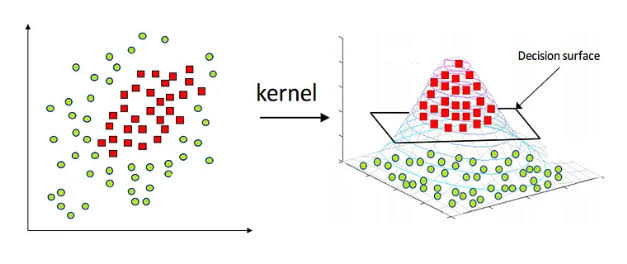

# Kernel Support Vector Machine (Kernel SVM)

Up to this point, we have studied **Hard-Margin SVM** and **Soft-Margin SVM**. Both are powerful classifiers, but they share one important limitation:

> **They are fundamentally linear classifiers.**

Whether using a hard margin or a soft margin, the decision boundary is always a **straight hyperplane**.

- In **2D**, the boundary is a straight line.
- In **3D**, the boundary is a flat plane.
- In higher dimensions, it remains a **linear hyperplane**.

Although **Soft-Margin SVM** can tolerate noisy data and overlapping classes through **slack variables** ($\xi_i$), it **cannot** correctly classify data whose true relationship is inherently **non-linear**.

---

# Why Do We Need Kernel SVM?

Consider a dataset like the one below.

- The **positive class** forms a small cluster at the center.
- The **negative class** completely surrounds it in a circular ring.

Visually, the dataset resembles a **target board**.

```
        ○ ○ ○ ○ ○
     ○             ○
   ○      ■ ■ ■      ○
   ○      ■ ■ ■      ○
   ○      ■ ■ ■      ○
     ○             ○
        ○ ○ ○ ○ ○
```

Here,

- **■** = Positive class
- **○** = Negative class

No matter how many times you rotate or shift a straight line, it can never perfectly separate the two classes.

Even a **Soft-Margin SVM** will fail because it is still restricted to learning **only a linear boundary**.

This situation motivates the need for **Kernel SVM**, which allows SVMs to learn **curved**, **non-linear**, and **highly flexible** decision boundaries.

---

# 1. Geometric Intuition: The Origami Trick

Imagine a flat sheet of paper.

At the center is a cluster of **red squares**, while a ring of **green circles** surrounds them.

Your task is to separate the two groups using a perfectly straight ruler.

It is impossible.

No matter how you position the ruler, it always cuts through both classes.

---

## Folding the Paper

Now imagine lifting the center of the paper upward, like folding a piece of origami.

The flat paper transforms into a three-dimensional shape.

- The red squares move upward onto the top of a hill.
- The green circles remain down in the surrounding valley.

Instead of trying to separate them using a **line**, you can now place a **flat sheet of glass** horizontally through the hill.

That flat plane perfectly separates the two groups.

---

## Looking Back from Above

If you now project the three-dimensional surface back onto the original two-dimensional paper,

the intersection of the plane appears as a beautiful **curved boundary**—for example, a circle.

Although the separator was **linear in three dimensions**, it appears **non-linear in two dimensions**.

---

## The Key Geometric Insight

> **Data that cannot be separated by a straight hyperplane in a lower-dimensional space often becomes linearly separable after being projected into a higher-dimensional feature space.**

This is the central idea behind **Kernel SVM**.

---

# 2. Mapping Data into Higher Dimensions

Suppose each data point is represented as

$$
\mathbf{x}
=
(x_1,x_2).
$$

To make the data linearly separable, we transform it into a higher-dimensional space using a mapping function

$$
\Phi(\mathbf{x}).
$$

For example,

$$
\boxed{
\Phi(x_1,x_2)
=
\left(
x_1^2,
x_2^2,
\sqrt{2}x_1x_2
\right)
}
$$

Notice that

- the original data had **2 features**,
- the transformed data now has **3 features**.

The data has been projected into a higher-dimensional feature space.

In this new space,

the classes that originally overlapped may now become perfectly separable using a simple linear hyperplane.

---

# The Computational Challenge

Although this idea works beautifully in theory,

it quickly becomes computationally expensive.

Imagine a dataset with

- 100 features,
- 500 features,
- or even 10,000 features.

Applying polynomial transformations explicitly causes the number of generated features to explode.

For high-degree mappings,

the transformed feature space may contain **millions** of dimensions.

This creates several practical problems:

- enormous memory consumption,
- slower training,
- higher computational cost,
- poor scalability.

Directly computing the transformed coordinates is therefore impractical.

---

# 3. The Kernel Trick

Fortunately, Support Vector Machines possess a remarkable mathematical property.

When solving the optimization problem,

the algorithm **never actually requires the transformed feature vectors themselves**.

Instead,

it only requires the **dot product** between transformed samples.

Mathematically,

the optimization depends only on quantities of the form

$$
\boxed{
\Phi(\mathbf{x}_i)^\top
\Phi(\mathbf{x}_j)
}
$$

where

- $\mathbf{x}_i$
- $\mathbf{x}_j$

are two training samples.

---

## The Brilliant Observation

Instead of computing

$$
\Phi(\mathbf{x})
$$

explicitly,

we compute the dot product **directly** using a special function called a **Kernel Function**.

A kernel function is defined as

$$
\boxed{
K(\mathbf{x}_i,\mathbf{x}_j)
=
\Phi(\mathbf{x}_i)^\top
\Phi(\mathbf{x}_j)
}
$$

The remarkable part is that the kernel computes this value **without ever constructing the higher-dimensional vectors**.

This computational shortcut is known as the

> **Kernel Trick.**

---

# Example: Polynomial Kernel

One of the simplest kernels is the **Polynomial Kernel**.

It is defined as

$$
\boxed{
K(\mathbf{x}_i,\mathbf{x}_j)
=
(\mathbf{x}_i^\top\mathbf{x}_j+1)^2
}
$$

There are now two possible approaches.

---

## The Hard Way

1. Transform every point into a higher-dimensional feature space.
2. Compute the transformed vectors.
3. Calculate their dot product.

This approach is expensive.

---

## The Kernel Way

Instead,

1. Compute the ordinary dot product in the original feature space.
2. Add one.
3. Square the result.

No higher-dimensional vectors are ever created.

Yet,

the result is **exactly identical** to the transformed dot product.

This is why the Kernel Trick is often described as a computational **shortcut** or **mathematical cheat code**.

---

# Why the Kernel Trick Works

The SVM optimization algorithm depends only on pairwise similarities between samples.

Instead of asking

> "What are the coordinates after transformation?"

the algorithm only asks

> "How similar are these two transformed points?"

The kernel answers this question directly.

As a result,

Kernel SVM enjoys all the benefits of higher-dimensional feature spaces without paying the enormous computational cost of explicitly constructing them.

---

# 4. Common Kernel Functions

Several kernel functions are commonly used in machine learning.

Each produces a different type of decision boundary.

---

## Linear Kernel

The simplest kernel is

$$
\boxed{
K(\mathbf{x}_i,\mathbf{x}_j)
=
\mathbf{x}_i^\top\mathbf{x}_j
}
$$

### Characteristics

- Produces a straight decision boundary.
- Equivalent to a standard linear Soft-Margin SVM.
- Fastest kernel.
- Suitable for linearly separable or nearly linear datasets.

---

## Polynomial Kernel

The Polynomial Kernel is

$$
\boxed{
K(\mathbf{x}_i,\mathbf{x}_j)
=
(\mathbf{x}_i^\top\mathbf{x}_j+r)^d
}
$$

where

- $r$ is a constant,
- $d$ is the polynomial degree.

### Characteristics

- Learns curved decision boundaries.
- Captures polynomial relationships.
- Increasing $d$ creates increasingly complex boundaries.

---

## Radial Basis Function (RBF) Kernel

The most widely used kernel is the **Radial Basis Function (RBF)** kernel.

Its equation is

$$
\boxed{
K(\mathbf{x}_i,\mathbf{x}_j)
=
\exp
\left(
-\gamma
\|
\mathbf{x}_i-\mathbf{x}_j
\|^2
\right)
}
$$

where

- $\gamma$ controls how rapidly similarity decreases with distance.

### Characteristics

- Maps data into an effectively **infinite-dimensional feature space**.
- Produces smooth, highly flexible decision boundaries.
- Can isolate complex clusters of arbitrary shapes.
- Handles highly non-linear datasets extremely well.

Because of its flexibility and strong performance,

the **RBF Kernel** is considered the **industry standard** for most practical SVM applications.

---

# Comparison of Common Kernels

| Kernel | Mathematical Formula | Characteristics |
|---------|----------------------|-----------------|
| **Linear** | $K(\mathbf{x}_i,\mathbf{x}_j)=\mathbf{x}_i^\top\mathbf{x}_j$ | Straight decision boundary; equivalent to linear SVM. |
| **Polynomial** | $K(\mathbf{x}_i,\mathbf{x}_j)=(\mathbf{x}_i^\top\mathbf{x}_j+r)^d$ | Learns polynomial and curved boundaries. |
| **RBF (Gaussian)** | $K(\mathbf{x}_i,\mathbf{x}_j)=\exp\left(-\gamma\|\mathbf{x}_i-\mathbf{x}_j\|^2\right)$ | Highly flexible; maps data into an infinite-dimensional space and captures complex non-linear structures. |

---

# Applications of Kernel SVM

Kernel SVM is particularly useful whenever the relationship between features is highly non-linear.

Some common applications include

- Image classification
- Face recognition
- Handwriting recognition
- Medical diagnosis
- Fraud detection
- Bioinformatics
- Protein classification
- Gene expression analysis
- Text classification
- Spam filtering
- Customer behavior analysis
- Financial anomaly detection

---

# Summary

Kernel SVM overcomes the primary limitation of linear SVMs by enabling **non-linear decision boundaries**.

Instead of explicitly transforming data into a higher-dimensional feature space, it uses the **Kernel Trick**, which computes the required inner products directly through a kernel function.

Mathematically,

$$
\boxed{
K(\mathbf{x}_i,\mathbf{x}_j)
=
\Phi(\mathbf{x}_i)^\top
\Phi(\mathbf{x}_j)
}
$$

This allows Support Vector Machines to solve highly complex classification problems while remaining computationally efficient.

Among the available kernels,

the **Radial Basis Function (RBF) Kernel** is the most widely used because of its ability to model intricate non-linear patterns while maintaining excellent predictive performance across a broad range of real-world datasets.